In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

T_300=[-1.12937819771988,260.497837077717,-0.047057424904862,10.8540765449047]
T_400=[-1.27183083573186,260.640289715731,-0.0529929514889264,10.8600120714888]
T_500=[-1.50186820752136,260.870327087523,-0.0625778419801346,10.86959696198]
T_600=[-1.49888053176343,260.867339411763,-0.0624533554901285,10.8694724754899]
T_700=[-1.6303163428177,260.998775222821,-0.0679298476174601,10.8749489676174]
T_800=[-1.81069192900417,261.179150809006,-0.0754454970418514,10.8824646170418]
T_900=[-1.84992255692301,261.218381436925,-0.0770801065385748,10.8840992265387]
T_1000=[-2.17827487894732,261.546733758945,-0.0907614532894518,10.8977805732893]
T_1100=[-2.51960295881431,261.888061838814,-0.104983456617297,10.9120025766172]
T_1200=[-2.52585232292071,261.894311202919,-0.105243846788375,10.9122629667883]
T_1300=[-2.69027692431026,262.058735804309,-0.11209487184622,10.9191139918462]
T_1400=[-2.85971337328945,262.228172253289,-0.119154723887098,10.9261738438871]
T_1500=[-3.00689528832057,262.375354168319,-0.125287303680034,10.9323064236799]

# 初始化空字典
T_data = {}

# 定义温度范围
temperatures = range(300, 1600, 100)  # 从300到1500，每100一个间隔

# 使用循环将每个温度对应的数据写入字典
for temp in temperatures:
    # 构造变量名
    variable_name = f'T_{temp}'
    
    # 使用 eval() 获取变量的值，并存入字典
    T_data[variable_name] = eval(variable_name)

# 打印结果检查
print(T_data)


TC = []

{'T_300': [-1.12937819771988, 260.497837077717, -0.047057424904862, 10.8540765449047], 'T_400': [-1.27183083573186, 260.640289715731, -0.0529929514889264, 10.8600120714888], 'T_500': [-1.50186820752136, 260.870327087523, -0.0625778419801346, 10.86959696198], 'T_600': [-1.49888053176343, 260.867339411763, -0.0624533554901285, 10.8694724754899], 'T_700': [-1.6303163428177, 260.998775222821, -0.0679298476174601, 10.8749489676174], 'T_800': [-1.81069192900417, 261.179150809006, -0.0754454970418514, 10.8824646170418], 'T_900': [-1.84992255692301, 261.218381436925, -0.0770801065385748, 10.8840992265387], 'T_1000': [-2.17827487894732, 261.546733758945, -0.0907614532894518, 10.8977805732893], 'T_1100': [-2.51960295881431, 261.888061838814, -0.104983456617297, 10.9120025766172], 'T_1200': [-2.52585232292071, 261.894311202919, -0.105243846788375, 10.9122629667883], 'T_1300': [-2.69027692431026, 262.058735804309, -0.11209487184622, 10.9191139918462], 'T_1400': [-2.85971337328945, 262.228172253289

Thermal conductivity = 2.0981999162697678
Thermal conductivity = 1.916120781054882
Thermal conductivity = 1.7320358656467454
Thermal conductivity = 1.7902009642632926
Thermal conductivity = 1.6569075650756528
Thermal conductivity = 1.4501564154184252
Thermal conductivity = 1.3952912565160327
Thermal conductivity = 1.4926317401843745
Thermal conductivity = 1.3339821867455748
Thermal conductivity = 1.3465643933911933
Thermal conductivity = 1.3582786450028659
Thermal conductivity = 1.3566263810422157
Thermal conductivity = 1.2584904342372596


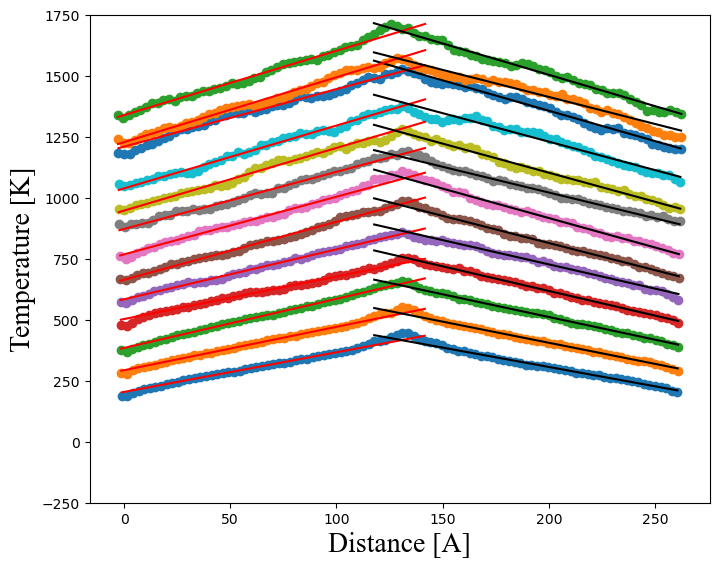

In [2]:
plt.figure(figsize=(8, 6.3333)) 
for i in np.linspace(300,1500,13):
    # 定义文件路径
    file_path = f'data_TC/profile_{int(i)}K.txt'
    
    # 读取文件内容
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    # 跳过文件前两行注释和第三行标题
    data_lines = lines[3:]
    
    # 创建一个空的列表来存储数据
    data = []
    
    # 解析数据行并将其添加到数据列表中
    group_size = 101
    for j in range(0, len(data_lines), group_size):
        group = data_lines[j+1:j+group_size]  # 跳过每组的第一行注释
        for line in group:
            if line.strip():  # 跳过空行
                columns = line.split()
                data.append(columns)
    # 定义列名
    columns = ['Chunk', 'Coord1', 'Ncount', 'v_temp']
    # 将数据转换为DataFrame
    df = pd.DataFrame(data, columns=columns)
    
    temp=[]
    for k in range(100):
        temp_l=[]
        for m in range(60)[:]:
            temp_l.append(float(df['v_temp'].iloc[m*100+k]))
        # print(np.mean(temp_l))
        temp.append(np.mean(temp_l))
        
    x = []
    for k in np.linspace(T_data[f'T_{int(i)}'][0],T_data[f'T_{int(i)}'][1],100):
        # print(k)
        x.append(k)
    y= temp
    
    x1=x[5:45]
    y1=y[5:45]
    x2=x[55:95]
    y2=y[55:95]
    
    coefficients1 = np.polyfit(x1, y1, 1)
    linear_fit1 = np.poly1d(coefficients1)

    coefficients2 = np.polyfit(x2, y2, 1)
    linear_fit2 = np.poly1d(coefficients2)

    # 创建一个折线图 
    plt.scatter(x, y, marker='o')  # 'o' 是点的样式
    plt.plot(x[:55], linear_fit1(x[:55]), color='red')
    plt.plot(x[45:], linear_fit2(x[45:]), color='black')
    
    # 添加标题和标签
    plt.title('Simple Line Plot')
    plt.xlabel('X Axis')
    plt.ylabel('Y Axis')
    plt.title("",size=20)
    # plt.xlabel("Distance [A]",size=20)
    # plt.ylabel("Temperature [K]",size=20)
    # plt.ylim(-500,1800)
    # plt.title("La2Zr2O7",size=20)

    A = (T_data[f'T_{int(i)}'][3] - T_data[f'T_{int(i)}'][2])**2 
    
    Thermal_conductivity1 = abs(0.5/2/coefficients1[0]/A*1.602/0.001)
    Thermal_conductivity2 = abs(0.5/2/coefficients2[0]/A*1.602/0.001)
        
    print('Thermal conductivity =', (Thermal_conductivity1+Thermal_conductivity2)/2)
    TC.append((Thermal_conductivity1+Thermal_conductivity2)/2)
    
# 显示图表
plt.ylim([-250,1750])
plt.xlabel("Distance [A]",fontsize=20, fontproperties=font_manager.FontProperties(fname='../../times.ttf'))
plt.ylabel("Temperature [K]",fontsize=20, fontproperties=font_manager.FontProperties(fname='../../times.ttf'))
plt.savefig('LZO.png', dpi=300, bbox_inches='tight')  # 保存为 PNG 格式，DPI 为 300，边界紧凑

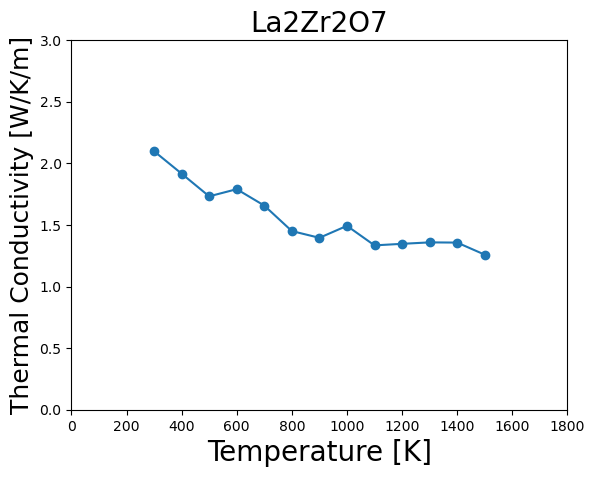

In [3]:
 # 创建一个折线图

plt.plot(np.linspace(300,1500,13), TC, marker='o')  # 'o' 是点的样式

# 添加标题和标签
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title("La2Zr2O7",size=20)
plt.xlabel("Temperature [K]",size=20)
plt.ylabel("Thermal Conductivity [W/K/m]",size=18)
plt.ylim(0,3)
plt.xlim(0,1800)

# 显示图表
plt.show()

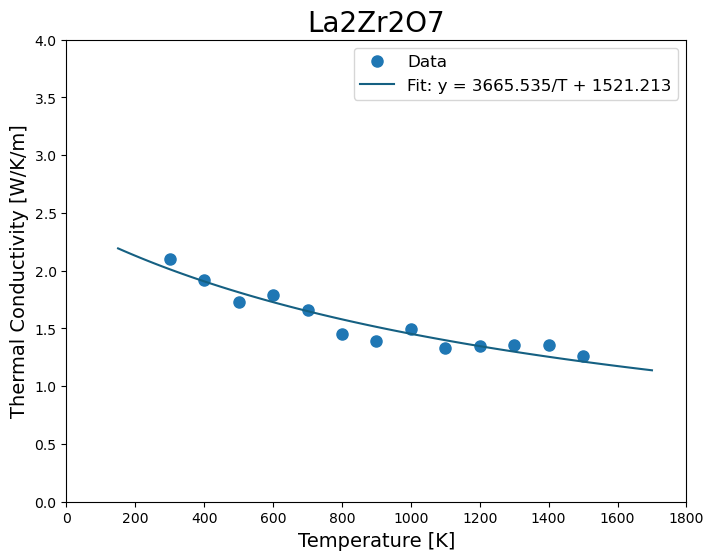

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 假设的数据点（请替换为实际数据）
temperature = np.linspace(300, 1500, 13)  # 温度 (K)
thermal_conductivity = np.array(TC)  # 热导率 (W/K/m)

# 定义拟合函数：y = a * (1/x) + b
def func(T, a, b):
    return a/ (T + b)

# 使用 curve_fit 进行非线性拟合
popt, pcov = curve_fit(func, temperature, thermal_conductivity)
a, b = popt  # 提取拟合参数

# 扩展拟合曲线范围为 50 K 到 1800 K
extended_temperature = np.linspace(150, 1700, 100)  # 更细致的温度范围
fitted_values = func(extended_temperature, a, b)

# 绘制原始数据点和拟合曲线
plt.figure(figsize=(8, 6))
plt.plot(temperature, thermal_conductivity, 'o', label="Data", markersize=8)
plt.plot(extended_temperature, fitted_values, '-', label=f"Fit: y = {a:.3f}/T + {b:.3f}", color = '#156082')
plt.xlabel("Temperature [K]", fontsize=14)
plt.ylabel("Thermal Conductivity [W/K/m]", fontsize=14)
plt.title("La2Zr2O7",size=20)
plt.legend(fontsize=12)
plt.ylim(0, 4)  # 调整y轴范围
plt.xlim(0, 1800)  # 调整x轴范围
plt.show()

In [6]:
for i,j in zip(extended_temperature, fitted_values):
    print(j)

2.1933381635295857
2.172980841088956
2.152997933810284
2.1333792063623136
2.114114793113936
2.095195181591607
2.0766111968171423
2.0583539864717126
2.0404150068356275
2.022786009456995
2.0054590285055522
1.9884263687709278
1.9716805942673499
1.9552145174093483
1.9390211887253435
1.9230938870781977
1.9074261103638144
1.8920115666607458
1.876844165805496
1.8619180113698237
1.8472273930178442
1.832766779222111
1.8185308103191675
1.8045142918862476
1.7907121884219324
1.7771196173146113
1.7637318430835742
1.7505442718784583
1.7375524462236376
1.7247520399949139
1.7121388536166227
1.699708809467954
1.6874579474879288
1.6753824209690786
1.6634784925304518
1.651742530261079
1.6401710040255444
1.6287604819237715
1.6175076268975563
1.6064091934768099
1.5954620246588378
1.584663048914356
1.574009277314283
1.5634978007716516
1.5531257873933078
1.5428904799363223
1.5327891933643185
1.5228193124991707
1.512978289763754
1.503263643011655
1.4936729534399633
1.484203863581449
1.4748540753726331
1.46562